In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files
import pandas as pd # Ensure pandas is imported

uploaded = files.upload()

# Assuming the uploaded file is the dataset and it's a CSV
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset.csv


In [ ]:
print("First 5 Records")
print(df.head())

First 5 Records
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2  

In [ ]:
print("\nDataset Shape:")
print(df.shape)



Dataset Shape:
(1200, 13)


In [ ]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [ ]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

### Linear Regression for Anxiety Level Prediction

Let's perform a linear regression to predict `anxiety_level` based on other numerical features. We'll split the data, train a model, evaluate its performance, and visualize the results.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Create a copy of the DataFrame to ensure the original 'df' remains unchanged for other tasks
# and to apply encoding specifically for regression if needed.
df_reg_encoded = df.copy()

# Identify and encode categorical columns for regression
label_encoder_reg = LabelEncoder()
categorical_columns_for_regression = df_reg_encoded.select_dtypes(include=['object']).columns

print(f"Categorical columns identified for regression encoding: {list(categorical_columns_for_regression)}")

for col in categorical_columns_for_regression:
    df_reg_encoded[col] = label_encoder_reg.fit_transform(df_reg_encoded[col])

# *** Debugging: Print dtypes after encoding ***
print("\nData types after encoding in df_reg_encoded:")
print(df_reg_encoded.dtypes[df_reg_encoded.dtypes == 'object'])

# Define features (X_reg) and target (y_reg) for regression using the encoded DataFrame
# Exclude 'anxiety_level' itself from features, and 'depression_label' as it's the target for classification
X_reg = df_reg_encoded.drop(['anxiety_level', 'depression_label'], axis=1)
y_reg = df_reg_encoded['anxiety_level']

# Split the data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"\nShape of X_train_reg: {X_train_reg.shape}")
print(f"Shape of X_test_reg: {X_test_reg.shape}")
print(f"Shape of y_train_reg: {y_train_reg.shape}")
print(f"Shape of y_test_reg: {y_test_reg.shape}")

Categorical columns identified for regression encoding: ['gender', 'platform_usage', 'social_interaction_level']

Data types after encoding in df_reg_encoded:
Series([], dtype: object)

Shape of X_train_reg: (960, 11)
Shape of X_test_reg: (240, 11)
Shape of y_train_reg: (960,)
Shape of y_test_reg: (240,)


In [ ]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = linear_model.predict(X_test_reg)

# Evaluate the model
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 2.52
Mean Squared Error (MSE): 8.41
Root Mean Squared Error (RMSE): 2.90
R-squared (R2): -0.02


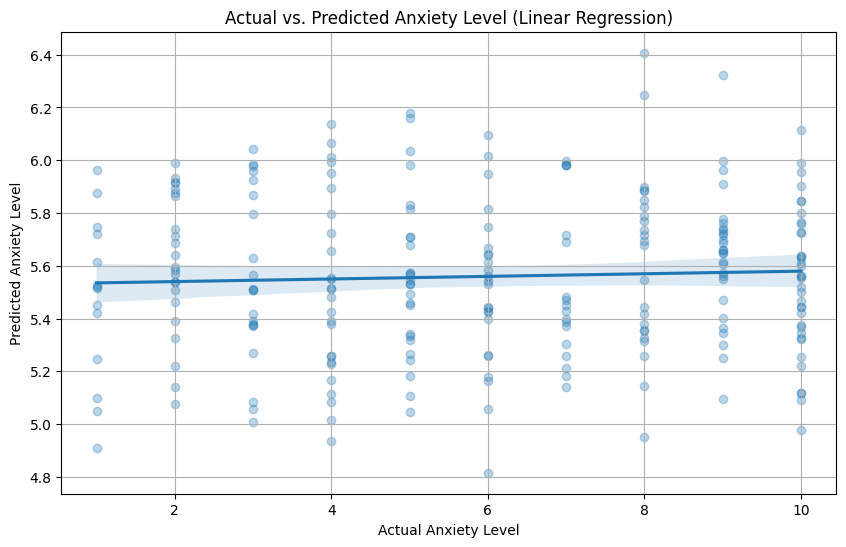

In [ ]:
# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Anxiety Level")
plt.ylabel("Predicted Anxiety Level")
plt.title("Actual vs. Predicted Anxiety Level (Linear Regression)")
plt.grid(True)
plt.show()

<Axes: >

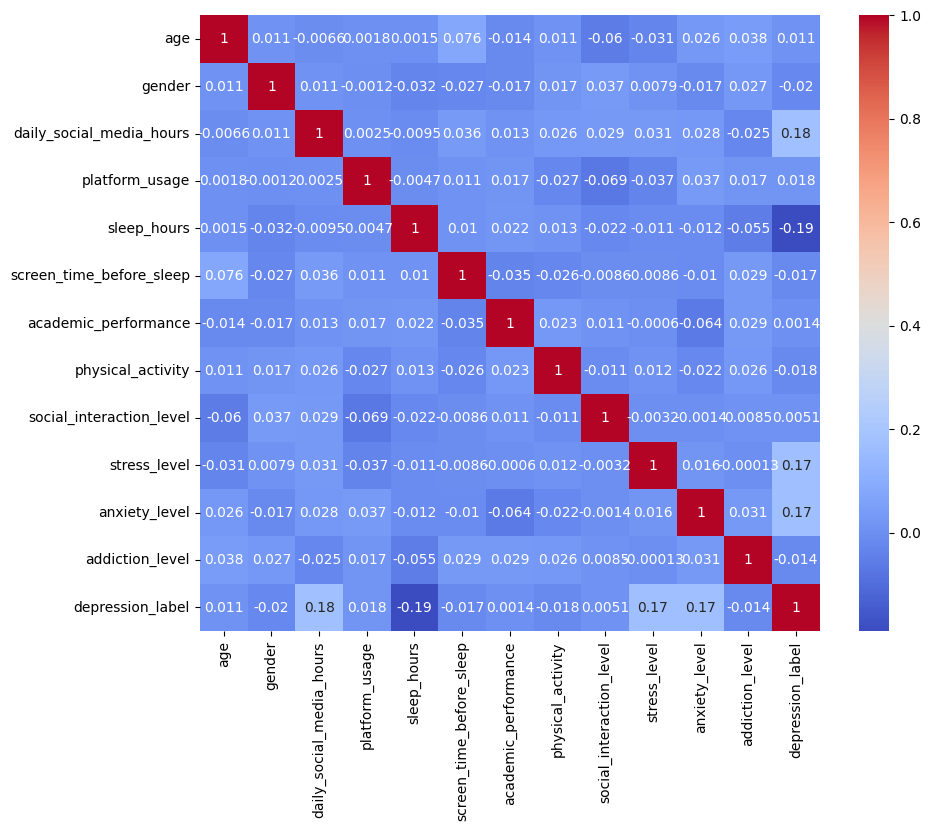

In [ ]:
df["depression_label"].value_counts()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [ ]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))


Accuracy:
0.9791666666666666


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[234   0]
 [  5   1]]


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



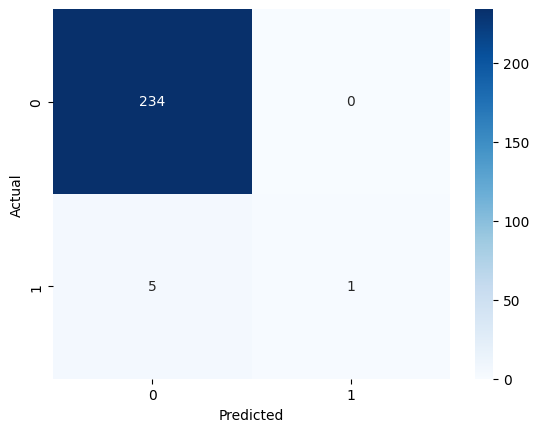

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

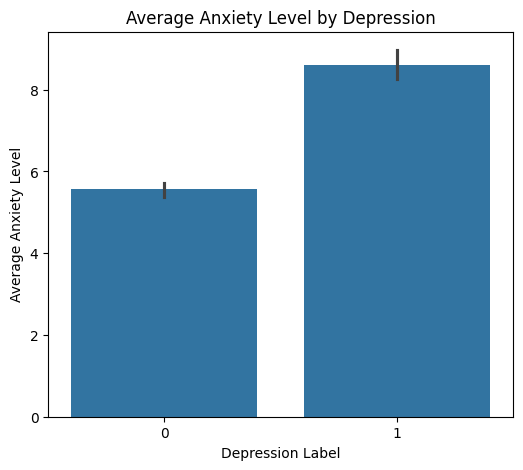

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.barplot(x='depression_label', y='anxiety_level', data=df)

plt.title('Average Anxiety Level by Depression')
plt.xlabel('Depression Label')
plt.ylabel('Average Anxiety Level')
plt.show()